# 리뷰 데이터 EDA

## 데이터 목록
- 교보
    - df = pd.read_csv('리뷰최종_교보베스트.csv')
    - df1 = pd.read_csv('리뷰최종_교보비베스트.csv')
    - test = pd.concat([df,df1])
    - 교보_베스트_단어빈도.csv
    - 교보_비베스트_단어빈도.csv
    - 교보_통합_단어빈도.csv

- 알라딘
    - df_al = pd.read_csv('리뷰최종_알라딘베스트.csv')
    - df_al1 = pd.read_csv('리뷰최종_알라딘비베스트.csv')
    - test1 = pd.concat([df_al, df_al1])
    - 알라딘_베스트_단어빈도.csv
    - 알라딘_비베스트_단어빈도.csv
    - 알라딘_통합_단어빈도.csv

- 예사
    - df_ys = pd.read_csv('리뷰최종_예사베스트.csv')
    - df_ys1 = pd.read_csv('리뷰최종_예사비베스트.csv')
    - test2 = pd.concat([df_ys, df_ys1])
    - 예스24_베스트_단어빈도.csv
    - 예스24_비베스트_단어빈도.csv
    - 예스24_통합_단어빈도.csv

- 영풍
    - df_yp = pd.read_csv('리뷰최종_영풍베스트.csv')
    - df_yp1 = pd.read_csv('리뷰최종_영풍비베스트.csv')
    - test3 = pd.concat([df_yp, df_yp1])
    - 영풍_베스트_단어빈도.csv
    - 영풍_비베스트_단어빈도.csv
    - 영풍_통합_단어빈도.csv

## 절차
1. 데이터 통합
2. 리뷰 길이 비교
3. 감성/별점 분포 시각화
4. 상관관계 분석

In [1]:
import pandas as pd
# 교보
df = pd.read_csv('리뷰최종_교보베스트.csv')
df1 = pd.read_csv('리뷰최종_교보비베스트.csv')
test = pd.concat([df,df1])

# 알라딘
df_al = pd.read_csv('리뷰최종_알라딘베스트.csv')
df_al1 = pd.read_csv('리뷰최종_알라딘비베스트.csv')
test1 = pd.concat([df_al, df_al1])

# 예사
df_ys = pd.read_csv('리뷰최종_예사베스트.csv')
df_ys1 = pd.read_csv('리뷰최종_예사비베스트.csv')
test2 = pd.concat([df_ys, df_ys1])

# 영풍
df_yp = pd.read_csv('리뷰최종_영풍베스트.csv')
df_yp1 = pd.read_csv('리뷰최종_영풍비베스트.csv')
test3 = pd.concat([df_yp, df_yp1])

## 1. 교보문고

In [ ]:
# review 길이(글자 수) 컬럼 생성
test['review_length'] = test['review'].astype(str).apply(len)

# 1점 리뷰 평균 길이
mean_len_1 = test.loc[test['rating'] == 1, 'review_length'].mean()

# 5점 리뷰 평균 길이
mean_len_5 = test.loc[test['rating'] == 5, 'review_length'].mean()

print(f"1점 리뷰 평균 길이: {mean_len_1:.2f} 글자")
print(f"5점 리뷰 평균 길이: {mean_len_5:.2f} 글자")

1점 리뷰 평균 길이: 117.57 글자
5점 리뷰 평균 길이: 81.33 글자


- 불만족 리뷰가 만족 리뷰보다 평균적으로 36자 이상 길다
<br>→ 불만족할수록 이유를 구체적으로 설명하는 경향이 있음

In [37]:
test['sentiment_binary'] = test['sentiment'].map({'긍정': 1, '부정': 0})

In [38]:
test.columns

Index(['isbn', 'review', 'rating', 'sentiment', 'sentiment_score',
       'review_length', 'sentiment_binary'],
      dtype='object')

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


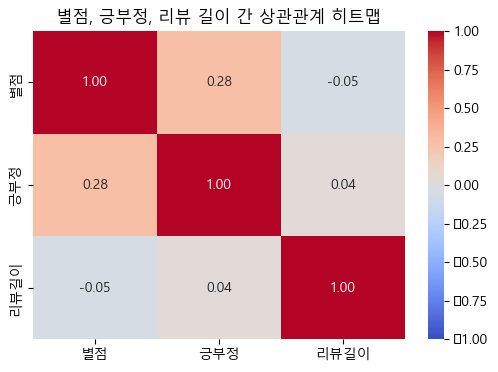

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'

# 리뷰 글자 수 계산
test['review_length'] = test['review'].astype(str).apply(len)
test['sentiment_binary'] = test['sentiment'].map({'긍정': 1, '부정': 0})

# 상관행렬 생성
corr_matrix = test[['rating', 'sentiment_binary', 'review_length']].corr()

# 히트맵 그리기
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    xticklabels=['별점', '긍부정', '리뷰길이'],
    yticklabels=['별점', '긍부정', '리뷰길이']
)
plt.title('별점, 긍부정, 리뷰 길이 간 상관관계 히트맵')
plt.show()

- 별점과 긍부정은 약한 양의 상관관계이다.
    - 별점이 높으면 대체로 긍정적인 리뷰일 가능성이 높음
    - 그러나 상관계수가 0.28로 아주 강하지는 않음
        - 별점이 높아도 내용상 불만'을 표현한 리뷰가 일부 존재한다는 뜻(표면상 긍정+내면상 불만 리뷰 혼재)

- 별점과 리뷰 길이는 거의 관계 없음
    - 상관계수 −0.05 → 별점이 높다고 해서 리뷰가 짧거나 길다는 경향은 거의 없음
    - 다만 살짝 음의 상관이므로 별점 낮은 리뷰가 조금 더 장문인 경우가 존재함
        - 불만족스러운 사용자는 이유를 자세히 설명하려는 경향이 있음.

- 리뷰 길이와 감성도 거의 무관
    - 0.04로 거의 상관 없음
    - 긍정/부정 감정이 리뷰 길이에 영향을 주지는 않음
        - 길게 쓴다고 더 긍정적이거나 부정적이지는 않다

In [ ]:
# 별점은 5점인데 감성 분석 결과는 부정인 리뷰들

test[(test['rating'] == 5) & (test['sentiment'] == '부정')]['review'][:20]

3      책은 얇고 가벼운데 그 안의 내용은 가볍지않아요 철학에 대한 기본베이스가 부족한 탓...
5                       재독 철학자 한병철 교수의 저작으로 번역본인 부분이 아쉽다
8      아무것도 생각하고 싶지않고 짜증만 났던 건 내가 너무 나를 착취한 결과인 것을 깨달았어요
13                                      저자의 책은 항상 실패가 없다
16                                         얇지만 깊이있는 책입니다
28                                조금 어려운 책이라 집중해서 읽고 있어요
43                                내용은 어렵지만 인싸이트를 주는 책입니다
93                              상당히 책이 얇네요 내용은 기대해 보겠습니다
144                                 원자폭탄이 탄생하게된 비밀스런 이야기
154                                         편히 영면하시길 빕니다
172                                            다 좋은데 번역이
174                        번역 얘기가 많네요 아이가 읽기에 어떨지 모르겠습니다
178    중등 아이가 만화로 한번 봐서 기대하고 읽기 시작했는데 번역이 거슬려서 못 읽겠다고...
188                민음사 세계문학전집 도전하려고 합니다 우선 얇은책부터 도전해보려구요
194                                       파리대왕 명성대로 좋은 책
255    매끄럽지 못한 번역이 드물지않게 보여서 책 읽는 속도가 안나고 그래서 좀 짜증이 났...
256                          문장을 보는 시간보다 생각하는 시간이 길어지는 책
303                         아직 

## 2. 알라딘

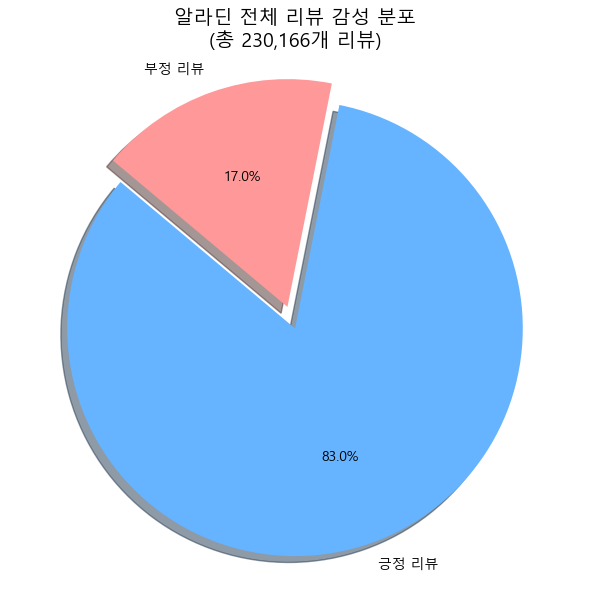

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 감성 분포 계산
sentiment_counts = test1['sentiment'].value_counts()

# 긍정/부정 수 추출
positive_reviews = sentiment_counts.get('긍정', 0)
negative_reviews = sentiment_counts.get('부정', 0)
total_reviews = positive_reviews + negative_reviews

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 원그래프 데이터 설정
labels = ['긍정 리뷰', '부정 리뷰']
sizes = [positive_reviews, negative_reviews]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)

# 원그래프 그리기
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%.1f%%',
    startangle=140,
    explode=explode,
    shadow=True
)
plt.title(f'알라딘 전체 리뷰 감성 분포\n(총 {total_reviews:,}개 리뷰)', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

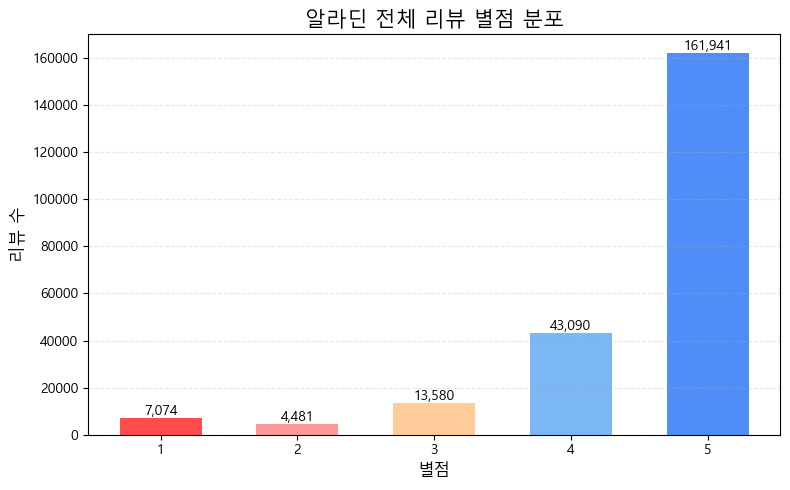

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# rating 값 카운팅 (빈도수 계산)
rating_counts = test1['rating'].value_counts().sort_index()

# x축: 별점, y축: 리뷰 수
ratings = rating_counts.index.tolist()      # 예: [1, 2, 3, 4, 5]
counts = rating_counts.values.tolist()      # 예: [391, 461, 1036, 4809, 23681]

# 색상 설정 (별점 낮을수록 붉은색, 높을수록 푸른색)
colors = ['#ff4c4c', '#ff9999', '#ffcc99', '#7bb6f5', '#4f8df7']  # 1~5점 순

# 막대그래프 그리기
plt.figure(figsize=(8, 5))
bars = plt.bar(ratings, counts, color=colors, width=0.6)

# 그래프 요소
plt.title('알라딘 전체 리뷰 별점 분포', fontsize=15)
plt.xlabel('별점', fontsize=12)
plt.ylabel('리뷰 수', fontsize=12)
plt.xticks(ratings)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 바 위에 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'{int(height):,}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [30]:
# review 길이(글자 수) 컬럼 생성
test1['review_length'] = test1['review'].astype(str).apply(len)

# 1점 리뷰 평균 길이
mean_len_1 = test1.loc[test1['rating'] == 1, 'review_length'].mean()

# 5점 리뷰 평균 길이
mean_len_5 = test1.loc[test1['rating'] == 5, 'review_length'].mean()

print(f"1점 리뷰 평균 길이: {mean_len_1:.2f} 글자")
print(f"5점 리뷰 평균 길이: {mean_len_5:.2f} 글자")

1점 리뷰 평균 길이: 100.79 글자
5점 리뷰 평균 길이: 370.01 글자


- 1점 리뷰는 '짜증나요','별로에요','실망이에요' 처럼 감정이 강하지만 간결한 표현이 많을 가능성이 읐음
- 5점 리뷰는 평균적으로 훨씬 긺.
    - 정성적 후기/추천 중심의 리뷰가 많음

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


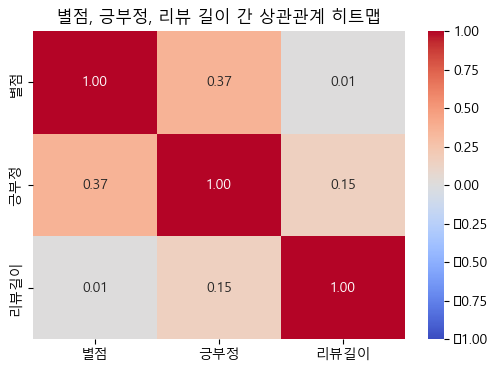

In [35]:
# 리뷰 글자 수 계산
test1['review_length'] = test1['review'].astype(str).apply(len)
test1['sentiment_binary'] = test1['sentiment'].map({'긍정': 1, '부정': 0})

# 상관행렬 생성
corr_matrix = test1[['rating', 'sentiment_binary', 'review_length']].corr()

# 히트맵 그리기
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    xticklabels=['별점', '긍부정', '리뷰길이'],
    yticklabels=['별점', '긍부정', '리뷰길이']
)
plt.title('별점, 긍부정, 리뷰 길이 간 상관관계 히트맵')
plt.show()

- 별점과 감성(긍/부정)은 함께 움직임
    - 별점이 높을수록 감성 분석 결과도 긍정적임
        - 사용자가 높은 별점을 줄 때는 실제로 긍정적인 어조로 리뷰를 작성한다는 의미
        - 별점과 텍스트 감성이 서로 일관된 신호를 주고 있음

- 별점과 리뷰 길이는 무관
    - 별점이 높거나 낮다고 해서 리뷰가 길어지거나 짧아지는 경향은 거의 없음
        - 별점은 즉각적 평가지만, 리뷰 길이는 개인 성향이나 리뷰 습관에 더 좌우되는 요소로 보임

- 긍정 리뷰는 약간 더 길다
    - 긍정일수록 글이 조금 더 길게 작성되는 경향
        - 만족한 사용자는 자신의 경험을 더 구체적으로 남김
    - 반대로 부정 리뷰는 짧고 감정적일 확률이 높음

In [19]:
test1[(test1['rating'] == 5) & (test1['sentiment'] == '부정')]['review'][20:40]

520                                     몸으로 나눈 가장 고결한 저항
531                                                낙엽 스낵
545                                    가을 그림책 낙엽스낵 웅진주니어
611                          마이리뷰 나는 인생에서 중요한 것만 남기기로 했다
614                        작심삼일의 의지 부족을 개선할 방법을 제시해주고 있음
615    수많은 핑계와 헛짓거리 속에서 보내는 무료한 일상을 탈출하게 해주는 안내서 이 책은...
617    작가가 나름 통찰력있구만 무슨 평점테러를 이렇게들 하시는지 자기계발서가 다 거기서 거기지
636                                             넌 나의 우주야
658                                     서평웅진주니어 넌 나의 우주야
660                                              기대하고있어요
661                                        넌 나의 우주야 읽어보기
669                              벚꽃 팝콘 향긋한 봄냄새와 봄맛나는 꽃팝콘
670                                                벚꽃 팝콘
672                                         꽃놀이 대신 벚꽃 팝콘
675    한국에서는 돈을 벌려면 부동산에 투자를 해야 한다고 합니다 주식 비트코인을 비롯해 ...
684    서울 아파트 포기하기엔 이르다 부동산시장은 언제나 밝은 미래만 예정되어 있는 곳이 ...
693                                            서울 아파트 지도
695                            

## 3. 예스24

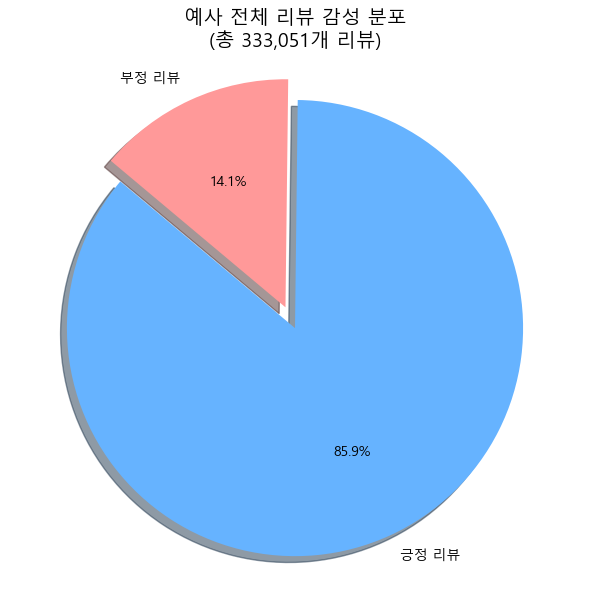

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 감성 분포 계산
sentiment_counts = test2['sentiment'].value_counts()

# 긍정/부정 수 추출
positive_reviews = sentiment_counts.get('긍정', 0)
negative_reviews = sentiment_counts.get('부정', 0)
total_reviews = positive_reviews + negative_reviews

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 원그래프 데이터 설정
labels = ['긍정 리뷰', '부정 리뷰']
sizes = [positive_reviews, negative_reviews]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)

# 원그래프 그리기
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%.1f%%',
    startangle=140,
    explode=explode,
    shadow=True
)
plt.title(f'예사 전체 리뷰 감성 분포\n(총 {total_reviews:,}개 리뷰)', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

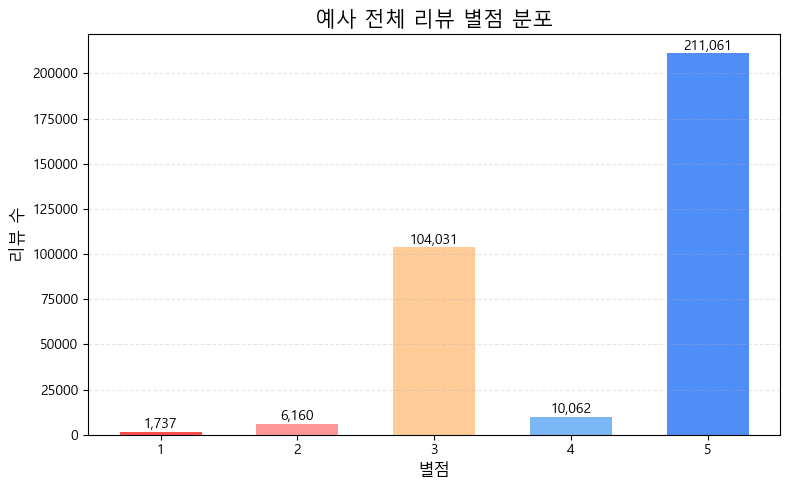

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# rating 값 카운팅 (빈도수 계산)
rating_counts = test2['rating'].value_counts().sort_index()

# x축: 별점, y축: 리뷰 수
ratings = rating_counts.index.tolist()      # 예: [1, 2, 3, 4, 5]
counts = rating_counts.values.tolist()      # 예: [391, 461, 1036, 4809, 23681]

# 색상 설정 (별점 낮을수록 붉은색, 높을수록 푸른색)
colors = ['#ff4c4c', '#ff9999', '#ffcc99', '#7bb6f5', '#4f8df7']  # 1~5점 순

# 막대그래프 그리기
plt.figure(figsize=(8, 5))
bars = plt.bar(ratings, counts, color=colors, width=0.6)

# 그래프 요소
plt.title('예사 전체 리뷰 별점 분포', fontsize=15)
plt.xlabel('별점', fontsize=12)
plt.ylabel('리뷰 수', fontsize=12)
plt.xticks(ratings)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 바 위에 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'{int(height):,}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [27]:
test2[test2['rating'] == 3]['review']

0           얇지만 생각할것이 많은 책입니다 감정과잉이 일어나지않게 올해는 유연하게 살아보려해요
1                                              우리는 모두 피로한가
2                                                 일독을 권합니다
3                                        철학적 사고의 동기부여가 된 책
4                                       이 시대 최고의 책으로 지정합시다
                               ...                        
71885    생각보다 책을보고 만들기는 쉽지 않아요 자세히 나와있지 않은 부분도 많고요 가격에 ...
72436    책읽기 삶읽기 142 사랑하면 노래를 불러야지요 사랑하면 보이는 나무허예섭허두영 씀...
72578    아이가 안네 프랑크를 좋아해서 이런저런 자료를 모으는 중이다 그래서 이 책에 기대가...
72980    지금은 챙겨보는 편은 아니지만 퀴즈프로그램을 좋아한다 어렸을 적에는 퀴즈탐험 신비의...
73138    흥미 있는 제목과는 달리 읽기가 꽤 힘들다 이유를 생각해 봤는데 큰 이유는 영어 번...
Name: review, Length: 104031, dtype: object

In [31]:
# review 길이(글자 수) 컬럼 생성
test2['review_length'] = test2['review'].astype(str).apply(len)

# 1점 리뷰 평균 길이
mean_len_1 = test2.loc[test2['rating'] == 1, 'review_length'].mean()

# 5점 리뷰 평균 길이
mean_len_5 = test2.loc[test2['rating'] == 5, 'review_length'].mean()

print(f"1점 리뷰 평균 길이: {mean_len_1:.2f} 글자")
print(f"5점 리뷰 평균 길이: {mean_len_5:.2f} 글자")

1점 리뷰 평균 길이: 32.44 글자
5점 리뷰 평균 길이: 187.94 글자


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


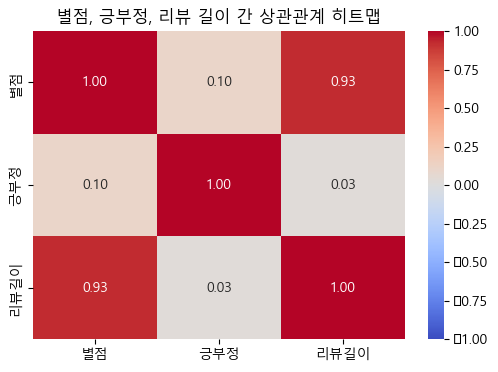

In [36]:
# 리뷰 글자 수 계산
test2['review_length'] = test2['review'].astype(str).apply(len)
test2['sentiment_binary'] = test2['sentiment'].map({'긍정': 1, '부정': 0})

# 상관행렬 생성
corr_matrix = test2[['rating', 'sentiment_binary', 'review_length']].corr()

# 히트맵 그리기
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    xticklabels=['별점', '긍부정', '리뷰길이'],
    yticklabels=['별점', '긍부정', '리뷰길이']
)
plt.title('별점, 긍부정, 리뷰 길이 간 상관관계 히트맵')
plt.show()

- 별점이 높을수록 리뷰가 길다
    - 이는 매우 강한 상관관계로, 만족한 독자일수록 자세히 리뷰를 작성하는 경향을 보여줌
        - 좋았던 점을 구체적으로 설명하려는 경향으로 해석 가능함
    - 반면 낮은 별점은 '별로임', '지루함' 같은 짧은 반응 중심일 수 있음

- 별점과 긍부정 감성은 약한 관련
    - 감성 분석은 별점과 어느 정도 일치하지만 강하진 않음
    - 높은 별점이 반드시 '긍정적 어조'의 리뷰로 이어지는 건 아니며 '비판적이지만 별점은 높게 주는' 케이스가 존재할 수 있음

- 긍부정 감성과 리뷰 길이는 거의 무관
    - 긍정 리뷰라고 해서 반드시 길거나 짧지 않음
    - 감성보다는 별점이 리뷰 길이에 더 큰 영향을 미침

In [23]:
test2[test2['rating'] == 3]['sentiment'].value_counts()

sentiment
긍정    90675
부정    13356
Name: count, dtype: int64

In [33]:
test2[test2['rating'] == 3]['review'][100:120]

104             오펜하이머는 천재지만 오펜하이머처럼 살고 싶지 않으며 권하고 싶지도 않다
105                                                 좋습니다
106                 양장판이 재입고 되어서 바로 구매했습니다 책 내용이 기대가 되네요
107                             아메리칸 프로메테우스 로버트 오펜하이머 평전
108                                         이런 종류의 책 좋아요
109                           영화의 감동을 책으로 다시한번 느껴보고 싶습니다
110                                   원자폭탄의 인생을 살은 오펜하이머
111                                              흥미로웠습니다
112            영화 속 인물들이 왜 그랬는가에 대해 훨씬 이해하기 수월합니다 흥미진진해요
113                          번역이 좋습니다 영화보기 전에 읽으려고 구매했어요
114       그래도 양장본이 나을것으로 판단해 구입했는데 역시 실망시키지 않네요 적극 추천합니다
115              도서관에서 여러번 빌려 읽다가 완독하지 못하고 ebook으로 도전합니다
116                                               재미있습니다
117                                    천재 과학자가 짊어져야 할 숙명
118           품부한 배경조사로 원자폭탄의 아버지라 불리우는 사람을 이해할 수 있었던 전기
120                            제목만 주구장창 들었던 책을 드디어 읽었습니다
121                                    똘레랑스를 항상 생각하게 되네여
122                           이

## 4. 영풍문고

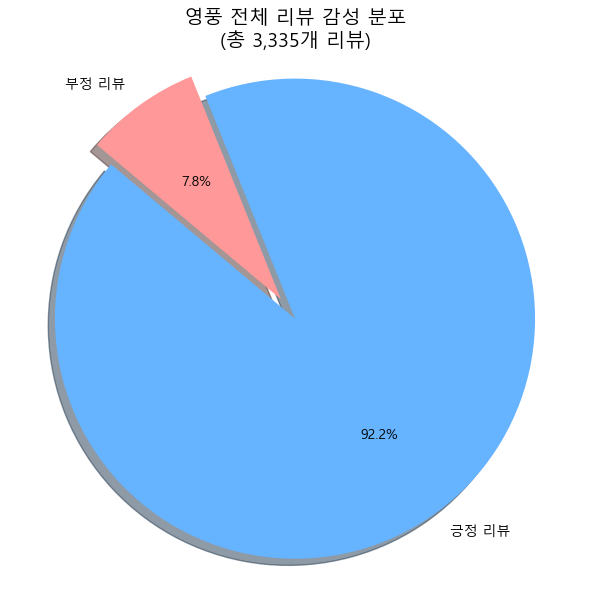

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# 감성 분포 계산
sentiment_counts = test3['sentiment'].value_counts()

# 긍정/부정 수 추출
positive_reviews = sentiment_counts.get('긍정', 0)
negative_reviews = sentiment_counts.get('부정', 0)
total_reviews = positive_reviews + negative_reviews

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 원그래프 데이터 설정
labels = ['긍정 리뷰', '부정 리뷰']
sizes = [positive_reviews, negative_reviews]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)

# 원그래프 그리기
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%.1f%%',
    startangle=140,
    explode=explode,
    shadow=True
)
plt.title(f'영풍 전체 리뷰 감성 분포\n(총 {total_reviews:,}개 리뷰)', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

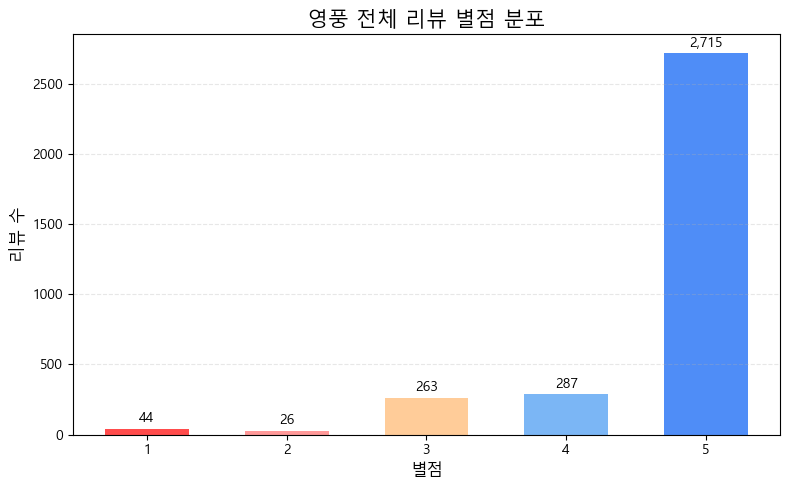

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# rating 값 카운팅 (빈도수 계산)
rating_counts = test3['rating'].value_counts().sort_index()

# x축: 별점, y축: 리뷰 수
ratings = rating_counts.index.tolist()      # 예: [1, 2, 3, 4, 5]
counts = rating_counts.values.tolist()      # 예: [391, 461, 1036, 4809, 23681]

# 색상 설정 (별점 낮을수록 붉은색, 높을수록 푸른색)
colors = ['#ff4c4c', '#ff9999', '#ffcc99', '#7bb6f5', '#4f8df7']  # 1~5점 순

# 최대 높이 계산 (숫자 위치 조정용)
max_height = max(counts)

# 막대그래프 그리기
plt.figure(figsize=(8, 5))
bars = plt.bar(ratings, counts, color=colors, width=0.6)

# 그래프 요소
plt.title('영풍 전체 리뷰 별점 분포', fontsize=15)
plt.xlabel('별점', fontsize=12)
plt.ylabel('리뷰 수', fontsize=12)
plt.xticks(ratings)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 바 위에 값 표시 (높이를 비례해서 조금 올림)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max_height * 0.01, 
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [32]:
# review 길이(글자 수) 컬럼 생성
test3['review_length'] = test3['review'].astype(str).apply(len)

# 1점 리뷰 평균 길이
mean_len_1 = test3.loc[test3['rating'] == 1, 'review_length'].mean()

# 5점 리뷰 평균 길이
mean_len_5 = test3.loc[test3['rating'] == 5, 'review_length'].mean()

print(f"1점 리뷰 평균 길이: {mean_len_1:.2f} 글자")
print(f"5점 리뷰 평균 길이: {mean_len_5:.2f} 글자")

1점 리뷰 평균 길이: 102.02 글자
5점 리뷰 평균 길이: 253.20 글자


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


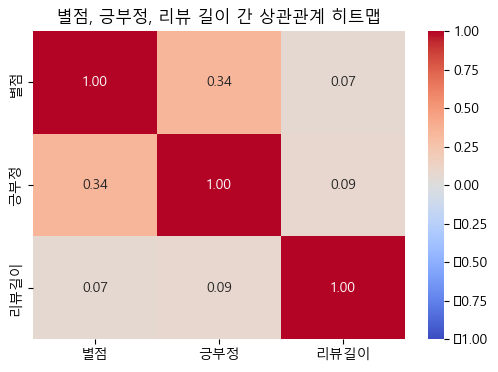

In [37]:
# 리뷰 글자 수 계산
test3['review_length'] = test3['review'].astype(str).apply(len)
test3['sentiment_binary'] = test3['sentiment'].map({'긍정': 1, '부정': 0})

# 상관행렬 생성
corr_matrix = test3[['rating', 'sentiment_binary', 'review_length']].corr()

# 히트맵 그리기
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    xticklabels=['별점', '긍부정', '리뷰길이'],
    yticklabels=['별점', '긍부정', '리뷰길이']
)
plt.title('별점, 긍부정, 리뷰 길이 간 상관관계 히트맵')
plt.show()

- 별점이 높을수록 긍정적인 감성으로 나타나는 경향이 있음
    - 별점과 감정은 일정 부분 일치하지만 완전하지 않음
        - 예: 높은 별점을 주더라도 어투가 차분하거나 비판적인 리뷰가 존재

- 리뷰 길이는 별점과 거의 관계가 없음
    - 짧은 리뷰든 긴 리뷰든 별점은 다양하게 분포됨
        - 독자의 만족도보다 리뷰 작성 성향(말이 많은 사람 vs 간결한 사람)이 영향을 준다

- 감성(긍정/부정)과 글자 수 역시 거의 상관 없음
    - 긍정 리뷰라도 짧을 수 있고, 부정 리뷰라도 장황할 수 있음

## 5. 그래프 통합

### a. 플랫폼별 전체 리뷰에서 긍정·부정 감성 비율 비교

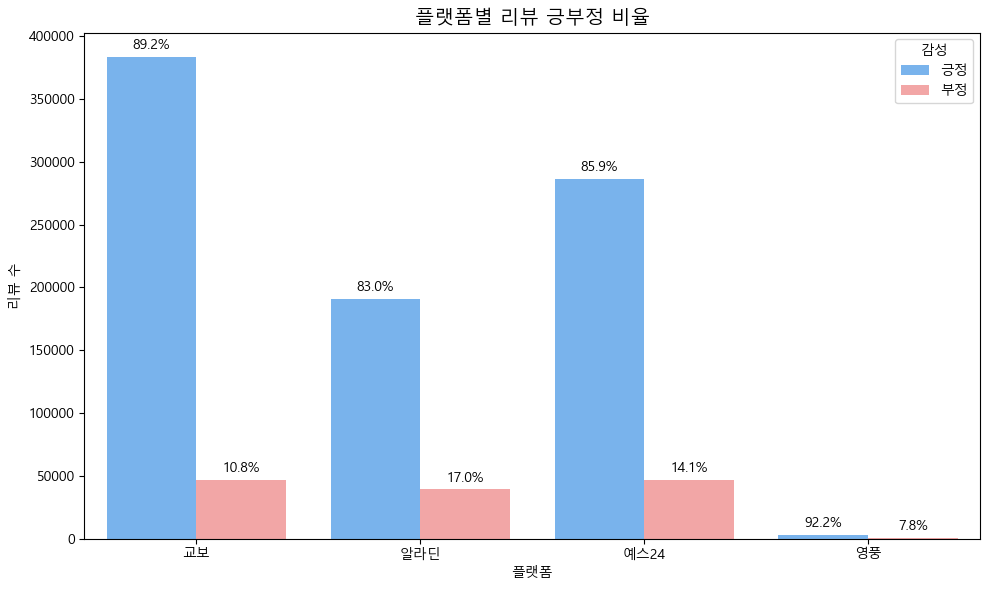

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터프레임 목록 및 이름
datasets = [test, test1, test2, test3]
labels = ['교보', '알라딘', '예스24', '영풍']

# 긍정/부정 개수를 저장할 리스트
sentiment_data = []

# 각 데이터셋에서 긍정/부정 수 계산
for label, df in zip(labels, datasets):
    sentiment_counts = df['sentiment'].value_counts()
    positive = sentiment_counts.get('긍정', 0)
    negative = sentiment_counts.get('부정', 0)
    total = positive + negative
    sentiment_data.append({'데이터셋': label, '감성': '긍정', '리뷰 수': positive, '비율': positive / total * 100})
    sentiment_data.append({'데이터셋': label, '감성': '부정', '리뷰 수': negative, '비율': negative / total * 100})

# 데이터프레임으로 변환
sentiment_df = pd.DataFrame(sentiment_data)

# 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='데이터셋',
    y='리뷰 수',
    hue='감성',
    data=sentiment_df,
    palette=['#66b3ff', '#ff9999']
)

# 막대 위에 비율 (%) 표시
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        label = bar.get_label()
        x = bar.get_x() + bar.get_width() / 2
        # 데이터셋명과 감성에 맞는 행을 찾기
        dataset_label = bar.get_x() + bar.get_width() / 2.0
        dataset = bar.get_x()
        bar_label = bar.get_label()
    # 정식 루프
for i, row in sentiment_df.iterrows():
    for bar in ax.patches:
        if bar.get_height() == row['리뷰 수']:
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_height()
            ax.text(x, y + max(sentiment_df['리뷰 수']) * 0.01,  # 약간 위에 표시
                    f"{row['비율']:.1f}%",
                    ha='center', va='bottom', fontsize=10)

# 제목, 라벨 등
plt.title('플랫폼별 리뷰 긍부정 비율', fontsize=14)
plt.xlabel('플랫폼')
plt.ylabel('리뷰 수')
plt.legend(title='감성')
plt.tight_layout()
plt.show()

- 전체적으로 긍정 리뷰가 압도적으로 많음
    - 네 플랫폼 모두 80% 이상이 긍정 리뷰
    - 이는 도서 자체의 만족도뿐 아니라 리뷰 작성자들이 주로 긍정적 경험을 공유하는 경향을 시사함

- 교보문고·영풍문고 → 긍정 피드백 중심 플랫폼
    - 특히 영풍문고는 긍정 비율이 92%로 만족도 최상위 그룹
    - 교보문고 역시 89% 이상으로 긍정 리뷰 중심적 생태계 형성

- 알라딘 → 상대적으로 의견 다양
    - 긍정 비율이 83%, 부정이 17%로 네 곳 중 부정 리뷰 비중이 가장 높음
    - 이는 커뮤니티 성격이 강하고, 비판적 독자층이 활발히 활동하는 알라딘 특성과 일치함

- 예스24 → 중간적 성향
    - 교보보다 약간 낮은 긍정 비율이나 전반적으로 긍정 중심 구조 유지
    - 다양한 장르/회원층이 공존하는 플랫폼의 특성을 반영함

### b. 플랫폼별 별점 분포 비교

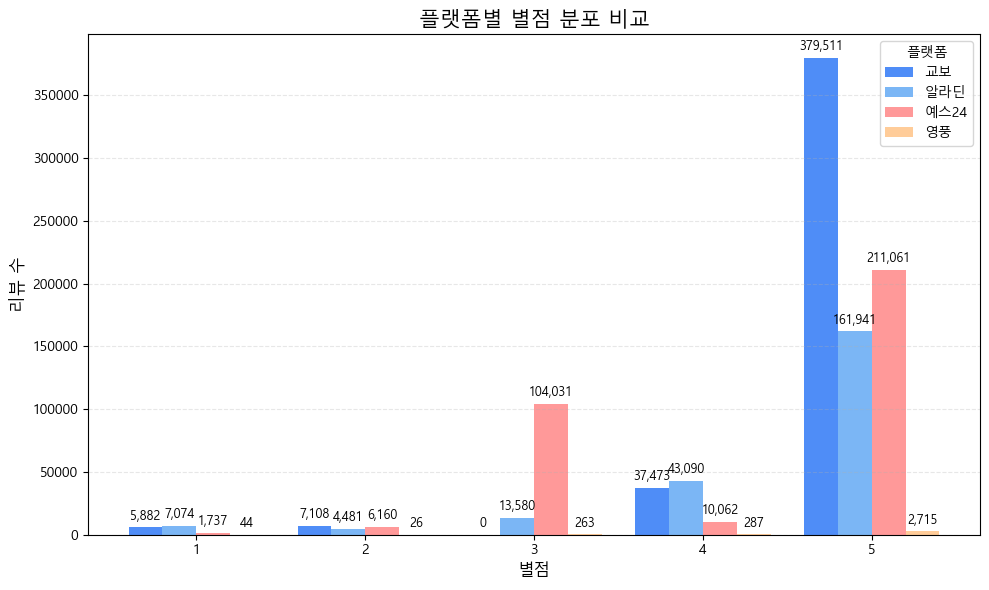

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. 데이터프레임 목록과 플랫폼 이름
datasets = [test, test1, test2, test3]
platforms = ['교보', '알라딘', '예스24', '영풍']

# 2. 별점 분포 집계
rating_range = [1, 2, 3, 4, 5]
rating_data = {platform: df['rating'].value_counts().reindex(rating_range, fill_value=0)
               for platform, df in zip(platforms, datasets)}

# 3. DataFrame 변환
rating_df = pd.DataFrame(rating_data, index=rating_range)  # index: 별점
rating_df.index.name = '별점'

# 4. 시각화 설정
x = np.arange(len(rating_range))  # [0, 1, 2, 3, 4]
bar_width = 0.2
colors = ['#4f8df7', '#7bb6f5', '#ff9999', '#ffcc99']  # 각 플랫폼 색상

plt.figure(figsize=(10, 6))

# 5. 막대그래프 그리기
for i, platform in enumerate(platforms):
    plt.bar(x + i * bar_width, rating_df[platform], width=bar_width, label=platform, color=colors[i])

# 6. 텍스트 표시
for i, platform in enumerate(platforms):
    for j, count in enumerate(rating_df[platform]):
        plt.text(x[j] + i * bar_width, count + max(rating_df.max()) * 0.01,
                 f'{int(count):,}', ha='center', va='bottom', fontsize=9)

# 7. 축, 제목 설정
plt.title('플랫폼별 별점 분포 비교', fontsize=15)
plt.xlabel('별점', fontsize=12)
plt.ylabel('리뷰 수', fontsize=12)
plt.xticks(x + bar_width * 1.5, rating_range)
plt.legend(title='플랫폼')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

- 전체적으로 5점 비중이 매우 높음
    - 네 플랫폼 모두 5점이 가장 많고 긍정 리뷰 중심의 구조를 가짐
    - 도서 리뷰 특성상 만족한 독자 중심의 후기 작성 경향을 반영

- 교보문고
    - 5점 리뷰가 약 38만 건으로 가장 많음
    - 4점 이하 분포가 얕아 긍정적 평가에 매우 치우친 구조
>> 이용자 충성도와 브랜드 신뢰도가 높다고 해석 가능함

- 알라딘
    - 4~5점이 주류이지만 1점도 많음 → 비판적 사용자층이 존재함
>> 플랫폼 내 다양한 성향의 독자들이 활발히 의견을 남기는 구조

- 예스24
    - 특이하게 3점 리뷰(약 10만 개)가 두드러짐
>> 긍/부정이 섞인 중립적/객관적 평가 경향을 의미하며 '좋지만 아쉽다', '보통이다' 같은 중간 평가가 많을 가능성이 있음

- 영풍문고
    - 전체 리뷰 수는 적지만 5점 비율이 압도적임
>> 리뷰가 소수지만 충성고객 중심의 긍정 후기가 대부분

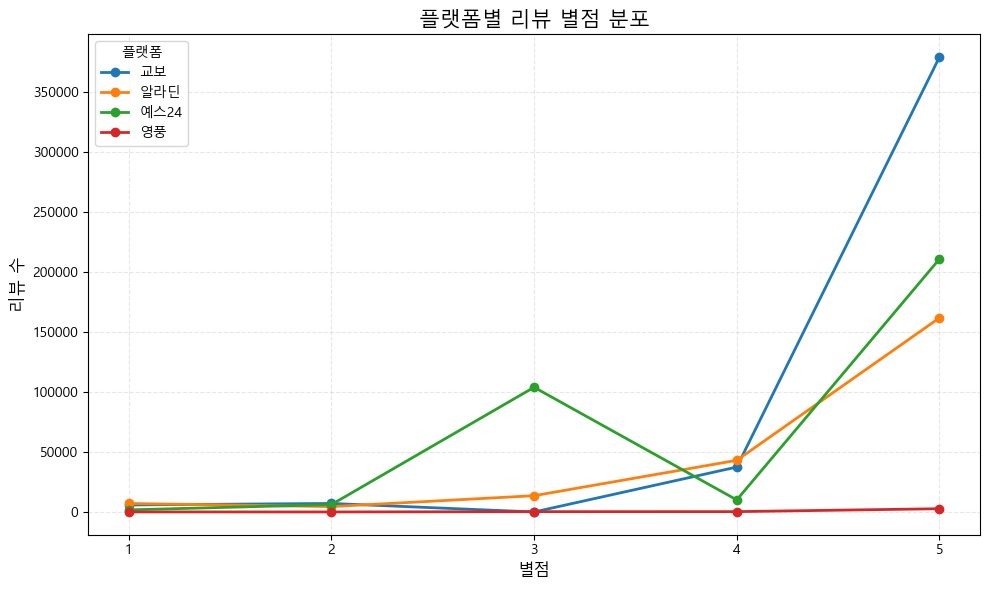

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터프레임 목록과 플랫폼 이름
datasets = [test, test1, test2, test3]
platforms = ['교보', '알라딘', '예스24', '영풍']
rating_range = [1, 2, 3, 4, 5]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 선 그래프 그리기
plt.figure(figsize=(10, 6))

for df, platform, color in zip(datasets, platforms, colors):
    # 별점 분포 계산 (누락된 별점은 0으로 채움)
    rating_counts = df['rating'].value_counts().reindex(rating_range, fill_value=0)
    
    plt.plot(
        rating_range,
        rating_counts.values,
        marker='o',
        label=platform,
        color=color,
        linewidth=2)

# 축, 제목, 범례 설정
plt.title('플랫폼별 리뷰 별점 분포', fontsize=15)
plt.xlabel('별점', fontsize=12)
plt.ylabel('리뷰 수', fontsize=12)
plt.xticks(rating_range)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='플랫폼')
plt.tight_layout()
plt.show()